# **E-Commerce Customer Analytics**
### **LTV Forecast**

**Notebook:** 05 of 06  
**Goal:** Forecast the 12-month customer lifetime value for every customer and segment the results by churn risk tier. This tells us not just who is likely to churn, but how much revenue is at stake if they do.

**Import Libraries**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

os.makedirs("/content/outputs/charts", exist_ok=True)
os.makedirs("/content/outputs/tables", exist_ok=True)

In [41]:
df = pd.read_csv(
    "customer_features_scored.csv",
    parse_dates=["FirstPurchaseDate", "LastPurchaseDate"]
)

In [42]:
df.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue,TenureDays,Churned,ChurnProbability,RiskTier
0,12346,326,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.60,0,1,0.969699,High Risk
1,12747,2,11,4196.01,2010-12-05 15:38:00,2011-12-07 14:34:00,381.46,366,0,0.000000,Low Risk
2,12748,1,210,33053.19,2010-12-01 12:48:00,2011-12-09 12:20:00,157.40,372,0,0.000000,Low Risk
3,12749,4,5,4090.88,2011-05-10 15:25:00,2011-12-06 09:56:00,818.18,209,0,0.028029,Medium Risk
4,12820,3,4,942.34,2011-01-17 12:34:00,2011-12-06 15:12:00,235.58,323,0,0.000000,Low Risk


In [43]:
print(f"Loaded: {df.shape[0]:,} customers × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Loaded: 3,921 customers × 11 columns
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'FirstPurchaseDate', 'LastPurchaseDate', 'AverageOrderValue', 'TenureDays', 'Churned', 'ChurnProbability', 'RiskTier']


**LTV Formula**

We use a 12-month LTV formula built from each customer's own purchase history, adjusted for their probability of churning:

LTV = Average Order Value × Purchase Frequency Per Year × (1 - Churn Probability)

The `(1 - Churn Probability)` term is the retention weight. It discounts the forecast based on how likely a customer is to leave. A customer with a churn probability of 0.97 has a retention weight of just 0.03 - meaning their projected value is reduced by 97%. A fully active customer with a churn probability of 0.00 keeps their full projected value untouched.

This makes the LTV honest. Without this adjustment, one-time buyers with high spend would appear as the most valuable customers in the portfolio which is misleading and unhelpful for any retention decision.

In [44]:
# Calculate the observation period per customer in years
df["ObservationYears"] = (df["TenureDays"] / 365).clip(lower=1/12)
df["FrequencyPerYear"] = df["Frequency"] / df["ObservationYears"]
df["RetentionWeight"] = 1 - df["ChurnProbability"]
df["LTV_12Month"] = (
    df["AverageOrderValue"] * df["FrequencyPerYear"] * df["RetentionWeight"]
).round(2)

In [45]:
df.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue,TenureDays,Churned,ChurnProbability,RiskTier,ObservationYears,FrequencyPerYear,RetentionWeight,LTV_12Month
0,12346,326,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.60,0,1,0.969699,High Risk,0.083333,12.000000,0.030301,28065.18
1,12747,2,11,4196.01,2010-12-05 15:38:00,2011-12-07 14:34:00,381.46,366,0,0.000000,Low Risk,1.002740,10.969945,1.000000,4184.60
2,12748,1,210,33053.19,2010-12-01 12:48:00,2011-12-09 12:20:00,157.40,372,0,0.000000,Low Risk,1.019178,206.048387,1.000000,32432.02
3,12749,4,5,4090.88,2011-05-10 15:25:00,2011-12-06 09:56:00,818.18,209,0,0.028029,Medium Risk,0.572603,8.732057,0.971971,6944.15
4,12820,3,4,942.34,2011-01-17 12:34:00,2011-12-06 15:12:00,235.58,323,0,0.000000,Low Risk,0.884932,4.520124,1.000000,1064.85


In [46]:
print(f"LTV Summary:")
print(df["LTV_12Month"].describe().round(2))

LTV Summary:
count      3921.00
mean       3385.29
std       10078.74
min           0.00
25%          21.29
50%        1520.49
75%        3923.64
max      294674.91
Name: LTV_12Month, dtype: float64


In [47]:
# Cap LTV at 99th percentile for summary stats
ltv_99 = df["LTV_12Month"].quantile(0.99)
print(f"99th percentile LTV : {ltv_99:,.2f}")
print(f"Customers above 99th: {(df['LTV_12Month'] > ltv_99).sum():,}")

99th percentile LTV : 28,267.39
Customers above 99th: 40


In [48]:
# LTV by Churn Risk Tier

tier_order = ["Low Risk", "Medium Risk", "High Risk"]

ltv_by_tier = df.groupby("RiskTier")["LTV_12Month"].agg(
    Customers   = "count",
    Mean_LTV    = "mean",
    Median_LTV  = "median",
    Total_LTV   = "sum"
).reindex(tier_order).round(2)

In [49]:
print("12-Month LTV by Risk Tier")
print(ltv_by_tier.to_string())

12-Month LTV by Risk Tier
             Customers  Mean_LTV  Median_LTV   Total_LTV
RiskTier                                                
Low Risk          1073   5082.55     2983.32  5453574.33
Medium Risk       1541   5018.13     2770.36  7732937.90
High Risk         1307     66.72        3.49    87203.82


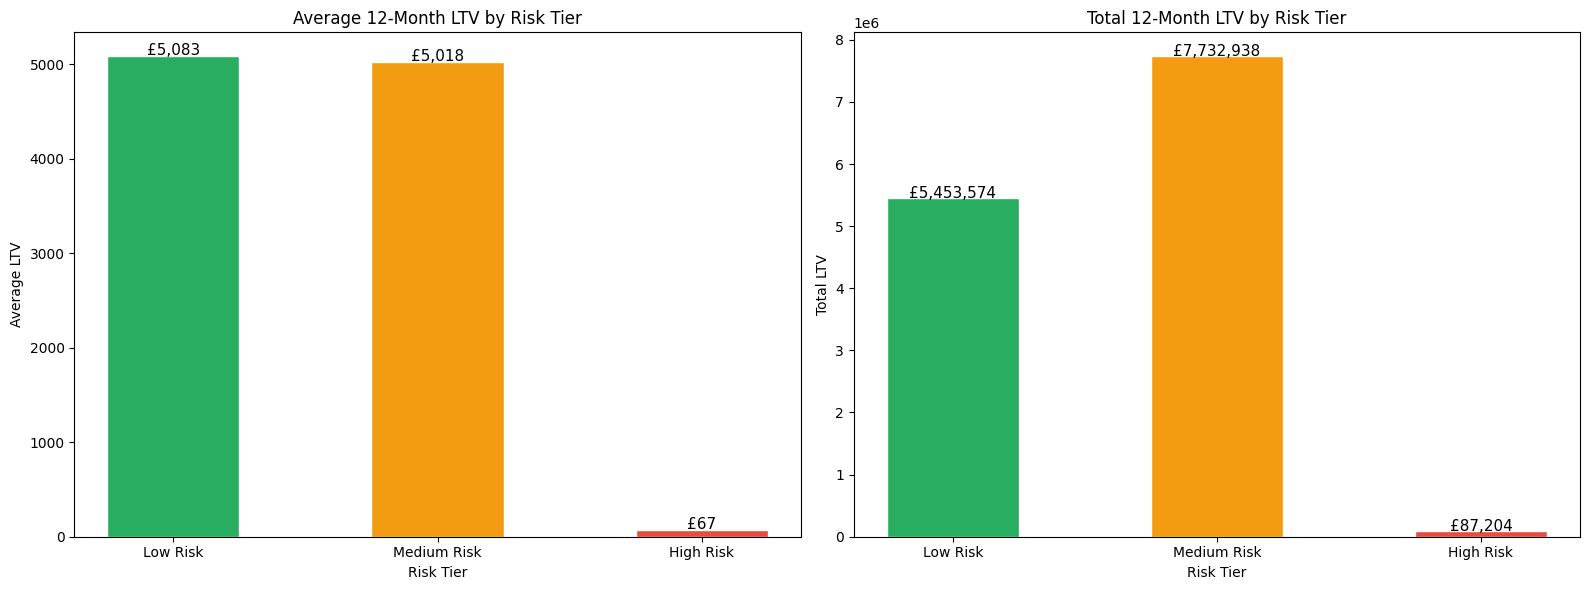

In [50]:
# Mean LTV bar chart by risk tier
colors     = ["#27ae60", "#f39c12", "#e74c3c"]
mean_ltv   = [ltv_by_tier.loc[t, "Mean_LTV"] for t in tier_order]
total_ltv  = [ltv_by_tier.loc[t, "Total_LTV"] for t in tier_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean LTV
axes[0].bar(tier_order, mean_ltv, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Average 12-Month LTV by Risk Tier")
axes[0].set_ylabel("Average LTV")
axes[0].set_xlabel("Risk Tier")
for i, v in enumerate(mean_ltv):
    axes[0].text(i, v + 10, f"£{v:,.0f}", ha="center", fontsize=11)

# Total LTV
axes[1].bar(tier_order, total_ltv, color=colors, edgecolor="white", width=0.5)
axes[1].set_title("Total 12-Month LTV by Risk Tier")
axes[1].set_ylabel("Total LTV")
axes[1].set_xlabel("Risk Tier")
for i, v in enumerate(total_ltv):
    axes[1].text(i, v + 100, f"£{v:,.0f}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("/content/outputs/charts/14_ltv_by_risk_tier.png", dpi=150)
plt.show()

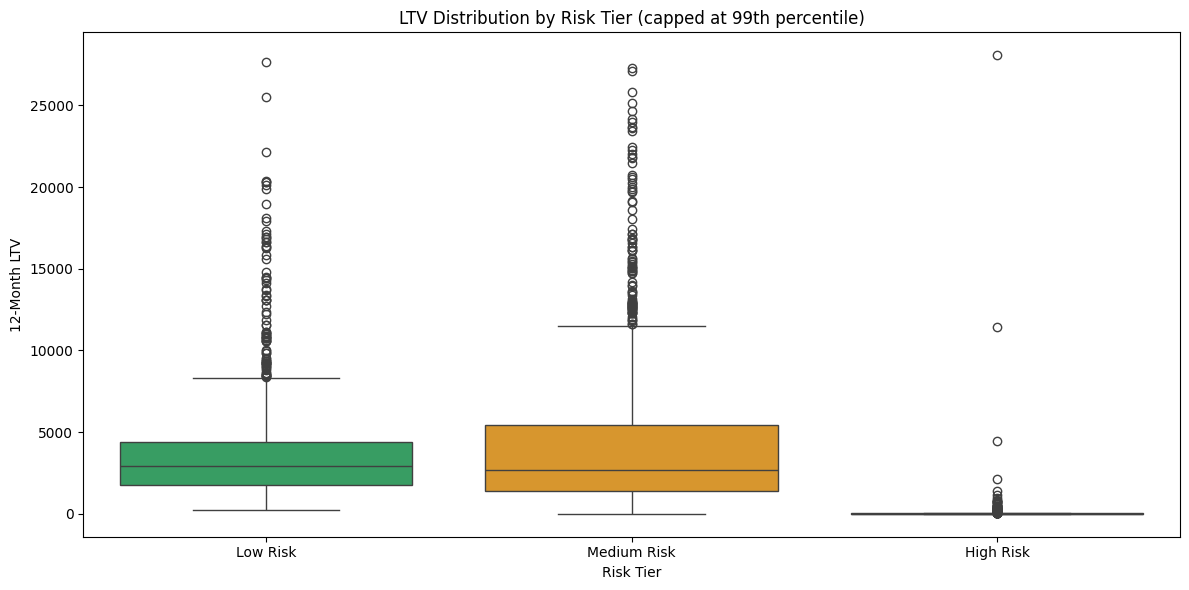

In [51]:
# LTV Distribution by Risk Tier
plot_df = df[df["LTV_12Month"] <= ltv_99].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=plot_df, x="RiskTier", y="LTV_12Month",
    order=tier_order,
    palette={"Low Risk": "#27ae60", "Medium Risk": "#f39c12", "High Risk": "#e74c3c"},
    ax=ax
)
ax.set_title("LTV Distribution by Risk Tier (capped at 99th percentile)")
ax.set_xlabel("Risk Tier")
ax.set_ylabel("12-Month LTV")

plt.tight_layout()
plt.savefig("/content/outputs/charts/15_ltv_distribution_boxplot.png", dpi=150)
plt.show()

In [52]:
# Revenue at Risk
high_risk_ltv    = ltv_by_tier.loc["High Risk",   "Total_LTV"]
medium_risk_ltv  = ltv_by_tier.loc["Medium Risk", "Total_LTV"]
total_at_risk    = high_risk_ltv + medium_risk_ltv
total_all        = ltv_by_tier["Total_LTV"].sum()
pct_at_risk      = (total_at_risk / total_all) * 100

print(f"High Risk LTV : {high_risk_ltv:>12,.2f}")
print(f"Medium Risk LTV : {medium_risk_ltv:>12,.2f}")
print(f"Total at Risk : {total_at_risk:>12,.2f}")
print(f"Total Portfolio : {total_all:>12,.2f}")
print(f"% at Risk : {pct_at_risk:.1f}%")

High Risk LTV :    87,203.82
Medium Risk LTV : 7,732,937.90
Total at Risk : 7,820,141.72
Total Portfolio : 13,273,716.05
% at Risk : 58.9%


In [53]:
# Top Value Customers by Tier

for tier in tier_order:
    print(f"\nTop 5 Customers - {tier}")
    top = (
        df[df["RiskTier"] == tier]
        [["CustomerID", "Recency", "Frequency", "Monetary",
          "AverageOrderValue", "LTV_12Month"]]
        .sort_values("LTV_12Month", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )
    top["LTV_12Month"] = top["LTV_12Month"].map(lambda x: f"{x:,.2f}")
    top["Monetary"]    = top["Monetary"].map(lambda x: f"{x:,.2f}")
    print(top.to_string(index=False))


Top 5 Customers - Low Risk
 CustomerID  Recency  Frequency   Monetary  AverageOrderValue LTV_12Month
      18102        1         60 259,657.30            4327.62  258,947.75
      17450        8         46 194,390.79            4225.89  197,639.81
      17511        3         31  91,062.38            2937.50   89,831.93
      16684        4         28  66,653.56            2380.48   68,919.28
      13694        4         50  65,039.62            1300.79   64,334.46

Top 5 Customers - Medium Risk
 CustomerID  Recency  Frequency   Monetary  AverageOrderValue LTV_12Month
      16446        1          2 168,472.50           84236.25  294,674.91
      14096        4         17  65,164.79            3833.22  238,072.36
      16000        3          3  12,393.70            4131.23  144,846.40
      18139       18          6   8,438.34            1406.39   98,526.30
      16029       39         63  80,850.84            1283.35   87,993.53

Top 5 Customers - High Risk
 CustomerID  Recency  Fr

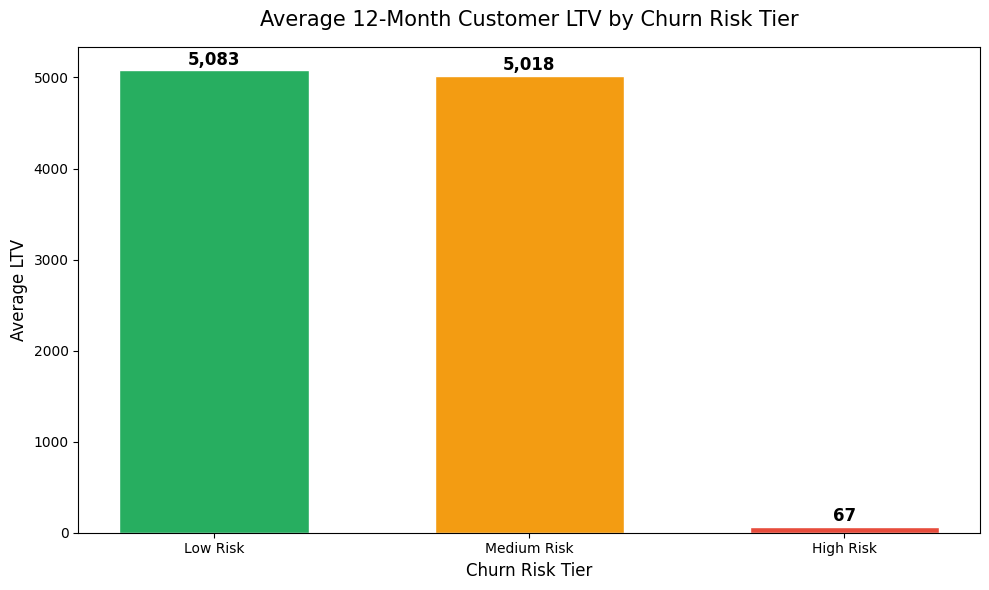

In [54]:
# LTV Segment Chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    tier_order, mean_ltv,
    color=colors, edgecolor="white", width=0.6
)

ax.set_title("Average 12-Month Customer LTV by Churn Risk Tier", fontsize=15, pad=15)
ax.set_ylabel("Average LTV", fontsize=12)
ax.set_xlabel("Churn Risk Tier", fontsize=12)

for bar, val in zip(bars, mean_ltv):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{val:,.0f}",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

plt.tight_layout()
plt.savefig("/content/outputs/charts/16_ltv_client_facing.png", dpi=150)
plt.show()

In [55]:
ltv_output = df[[
    "CustomerID", "Recency", "Frequency", "Monetary",
    "AverageOrderValue", "LTV_12Month", "ChurnProbability", "RiskTier"
]].sort_values("LTV_12Month", ascending=False).reset_index(drop=True)
ltv_output.head()

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,LTV_12Month,ChurnProbability,RiskTier
0,16446,1,2,168472.50,84236.25,294674.91,0.022422,Medium Risk
1,18102,1,60,259657.30,4327.62,258947.75,0.000000,Low Risk
2,14096,4,17,65164.79,3833.22,238072.36,0.029098,Medium Risk
3,17450,8,46,194390.79,4225.89,197639.81,0.000000,Low Risk
4,16000,3,3,12393.70,4131.23,144846.40,0.026074,Medium Risk


In [56]:
df.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue,TenureDays,Churned,ChurnProbability,RiskTier,ObservationYears,FrequencyPerYear,RetentionWeight,LTV_12Month
0,12346,326,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.60,0,1,0.969699,High Risk,0.083333,12.000000,0.030301,28065.18
1,12747,2,11,4196.01,2010-12-05 15:38:00,2011-12-07 14:34:00,381.46,366,0,0.000000,Low Risk,1.002740,10.969945,1.000000,4184.60
2,12748,1,210,33053.19,2010-12-01 12:48:00,2011-12-09 12:20:00,157.40,372,0,0.000000,Low Risk,1.019178,206.048387,1.000000,32432.02
3,12749,4,5,4090.88,2011-05-10 15:25:00,2011-12-06 09:56:00,818.18,209,0,0.028029,Medium Risk,0.572603,8.732057,0.971971,6944.15
4,12820,3,4,942.34,2011-01-17 12:34:00,2011-12-06 15:12:00,235.58,323,0,0.000000,Low Risk,0.884932,4.520124,1.000000,1064.85


In [57]:
# Save the LTV table
ltv_output.to_csv("ltv_forecast_table.csv", index=False)

# Save updated customer df
df.to_csv("customer_features_ltv.csv", index=False)